In [4]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy import stats
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR

# Раздел 1. Предварительный анализ исходных данных


In [5]:
df_raw = pd.read_csv("laptop_price.csv", encoding = "latin-1")
df_raw = df_raw.iloc[750:850]

df = pd.DataFrame()
df["price_euros"] = df_raw["Price_euros"]
df["ram"] = df_raw["Ram"].str.replace("GB", "").astype(float)
df["weight"] = df_raw["Weight"].str.replace("kg", "").astype(float)
df["inches"] = df_raw["Inches"]
df['typename'] = df_raw['TypeName']
df['cpu'] = df_raw['Cpu'].str.extract(r'(\d+\.?\d*)\s*GHz')
df['cpu'] = pd.to_numeric(df['cpu'])

In [6]:
df['memory'] = df_raw['Memory']
df['memory'] = df['memory'].str.replace('GB', '')
df['memory'] = df['memory'].str.replace('TB', '')
df['memory'] = df['memory'].str.replace('SSD', '')
df['memory'] = df['memory'].str.replace('HDD', '')
df['memory'] = df['memory'].str.replace('1 ', '1024')
df['memory'] = df['memory'].str.replace('128 + 1', '1152')
df['memory'] = df['memory'].str.replace('256 + 1', '1280')
df['memory'] = df['memory'].str.replace('1 + 1', '2048')
df['memory'] = df['memory'].str.replace('Flash Storage', '')
df['memory'] = df['memory'].str.replace('128  +  1024', '1152')
df['memory'] = df['memory'].str.replace('256  +  1024', '1280')
df['memory'] = df['memory'].str.replace('256  +  2', '2304')
df['memory'] = df['memory'].str.replace('1024 +  1024', '2048')
df['memory'] = df['memory'].str.replace('512  +  1024', '1536')
df['memory'] = pd.to_numeric(df['memory'])
df.loc[df['memory'] == 2, 'memory'] = 2048

In [7]:
df['gpu'] = df_raw['Gpu']

gpu_scores = {
    'intel hd graphics 400': 300, 'intel hd graphics 520': 1050, 'nvidia geforce gtx 950m': 4500, 'intel hd graphics 620': 1100,
    'intel hd graphics 540': 900, 'nvidia geforce gtx 1050': 6500, 'nvidia quadro m1000m': 4800, 'nvidia geforce gtx 1070': 14800,
    'intel hd graphics 615': 450, 'nvidia geforce 920mx': 650, 'nvidia geforce gtx 960m': 5200, 'intel hd graphics 505': 250,
    'amd radeon r7 m445': 800, 'amd radeon 540': 4200, 'nvidia geforce 940mx': 3800, 'nvidia quadro m2000m': 5800,
    'nvidia geforce gtx 1060': 10800, 'nvidia geforce gtx 1070m': 11200, 'nvidia geforce 930m': 700,
    'intel hd graphics 405': 280, 'nvidia geforce gtx1060': 10800, 'intel hd graphics 500': 200,
    'amd radeon r7 m460': 850, 'intel hd graphics 5300': 950, 'amd radeon r5 m420x': 500, 'nvidia quadro m2200': 6800,
    'amd radeon r7 graphics': 400, 'nvidia geforce gtx 1050 ti': 7200, 'nvidia geforce 920m': 600,
    'amd radeon rx 580': 11500, 'nvidia geforce gt 940mx': 3800, 'amd radeon r5 m420': 480, 'intel hd graphics 510': 350,
    'nvidia geforce gtx 1080': 16500, 'nvidia geforce 920': 550, 'nvidia geforce 930mx': 750, 'nvidia geforce 940m': 3800
}

gpu_keys = df['gpu'].astype(str).str.strip().str.lower()

df['gpu_score'] = gpu_keys.map(gpu_scores)

Размер выборки: 100

Типы данных:
price_euros    float64
ram            float64
weight         float64
inches         float64
typename        object
cpu            float64
memory           int64
gpu             object
gpu_score        int64
dtype: object

Характеристики числовых столбцов
       price_euros         ram      weight      inches         cpu  \
count   100.000000  100.000000  100.000000  100.000000  100.000000   
mean   1349.672400    9.200000    2.049600   14.751000    2.370000   
std     841.842053    5.839607    0.826151    1.516808    0.491236   
min     202.900000    4.000000    0.810000   11.600000    1.100000   
25%     732.747500    4.000000    1.400000   14.000000    2.300000   
50%    1114.000000    8.000000    1.965000   15.600000    2.500000   
75%    1814.000000    9.000000    2.400000   15.600000    2.700000   
max    5499.000000   32.000000    4.420000   17.300000    2.900000   

            memory     gpu_score  
count   100.000000    100.000000  
mean    56

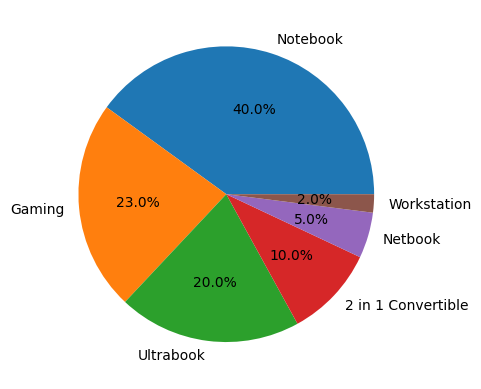


Количество не пустых значений на столбец:
price_euros    100
ram            100
weight         100
inches         100
typename       100
cpu            100
memory         100
gpu            100
gpu_score      100
dtype: int64


In [8]:
print(f'Размер выборки: {len(df_raw['laptop_ID'])}')
print(f'\nТипы данных:\n{df.dtypes}\n')

print(f'Характеристики числовых столбцов')
print(df.describe())

print()

cat_num = df['typename'].value_counts()
plt.pie(cat_num.values, labels = cat_num.index, autopct = '%1.1f%%')
plt.show()

print(f'\nКоличество не пустых значений на столбец:\n{df.isna().count(False)}')

df["typename"] = (df_raw["TypeName"] == "Gaming").astype(int)

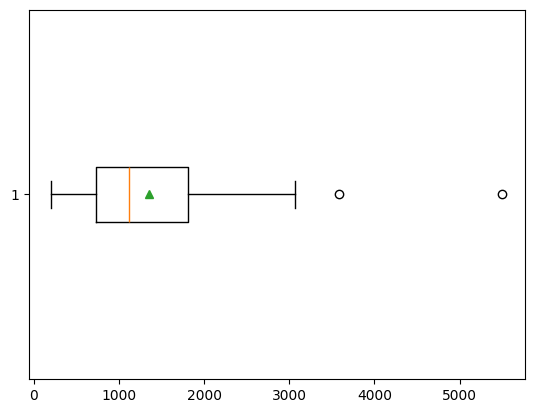

In [9]:
plt.boxplot(df['price_euros'], vert = False, showcaps = True, showmeans = True,)
plt.show()

# Раздел 2. Основной анализ данных


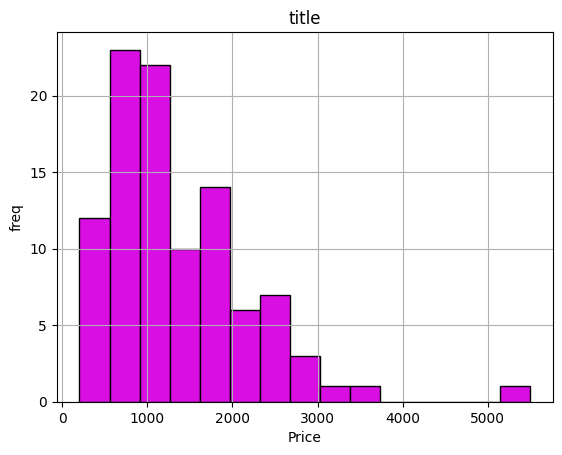

In [10]:
bins_num = 1 + (3.222 * math.log(100))
plt.hist(df['price_euros'], bins = int(bins_num), color = '#D90EE3', edgecolor = 'black' )
plt.title('title')
plt.xlabel('Price')
plt.ylabel('freq')
plt.grid(True)
plt.show()

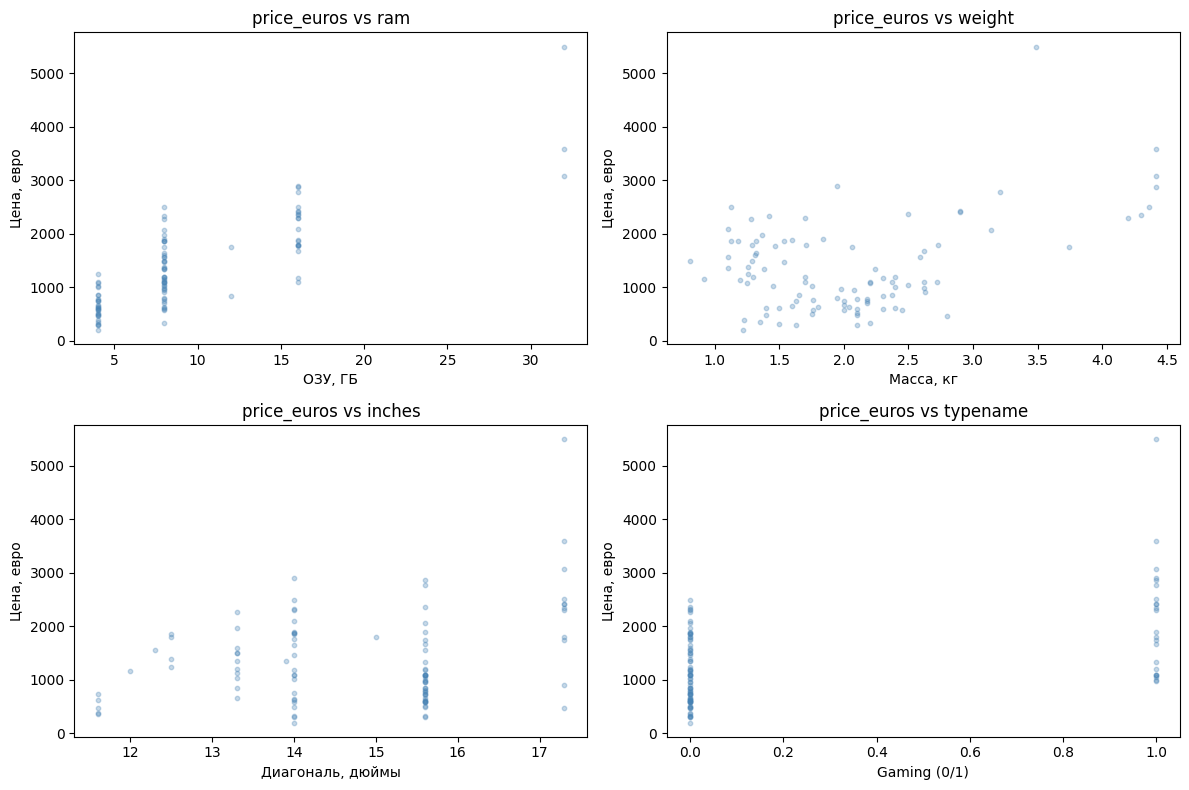

In [11]:
ig, axes = plt.subplots(2, 2, figsize=(12, 8))
pairs = [("ram", "ОЗУ, ГБ"), ("weight", "Масса, кг"),
         ("inches", "Диагональ, дюймы"), ("typename", "Gaming (0/1)")]
for ax, (col, label) in zip(axes.flatten(), pairs):
    ax.scatter(df[col], df["price_euros"], alpha=0.3, s=10, color="steelblue")
    ax.set_xlabel(label)
    ax.set_ylabel("Цена, евро")
    ax.set_title(f"price_euros vs {col}")
plt.tight_layout()
plt.show()

In [12]:
mean_price = df['price_euros'].mean()

median_price = df['price_euros'].median()

mode_price = df['price_euros'].mode()[0]

var_price = df['price_euros'].var()

std_price = df['price_euros'].std()

skewness = stats.skew(df['price_euros'])

kurt = stats.kurtosis(df['price_euros'])

print(f"Среднее: {mean_price:.2f}")
print(f"Медиана: {median_price:.2f}")
print(f"Мода: {mode_price:.2f}")
print(f"Дисперсия: {var_price:.2f}")
print(f"Стд. отклонение: {std_price:.2f}")
print(f'Асимметрия: {skewness:.4f}')
print(f'Эксцесс: {kurt:.4f}')

Среднее: 1349.67
Медиана: 1114.00
Мода: 1099.00
Дисперсия: 708698.04
Стд. отклонение: 841.84
Асимметрия: 1.5820
Эксцесс: 4.6047


Коэффициенты корреляции Пирсона
             price_euros    ram  weight  inches    cpu  memory  typename  \
price_euros        1.000  0.822   0.415   0.272  0.552   0.296     0.500   
ram                0.822  1.000   0.554   0.413  0.476   0.476     0.574   
weight             0.415  0.554   1.000   0.819  0.355   0.629     0.689   
inches             0.272  0.413   0.819   1.000  0.412   0.603     0.525   
cpu                0.552  0.476   0.355   0.412  1.000   0.336     0.413   
memory             0.296  0.476   0.629   0.603  0.336   1.000     0.587   
typename           0.500  0.574   0.689   0.525  0.413   0.587     1.000   
gpu_score          0.680  0.693   0.767   0.590  0.485   0.618     0.876   

             gpu_score  
price_euros      0.680  
ram              0.693  
weight           0.767  
inches           0.590  
cpu              0.485  
memory           0.618  
typename         0.876  
gpu_score        1.000  


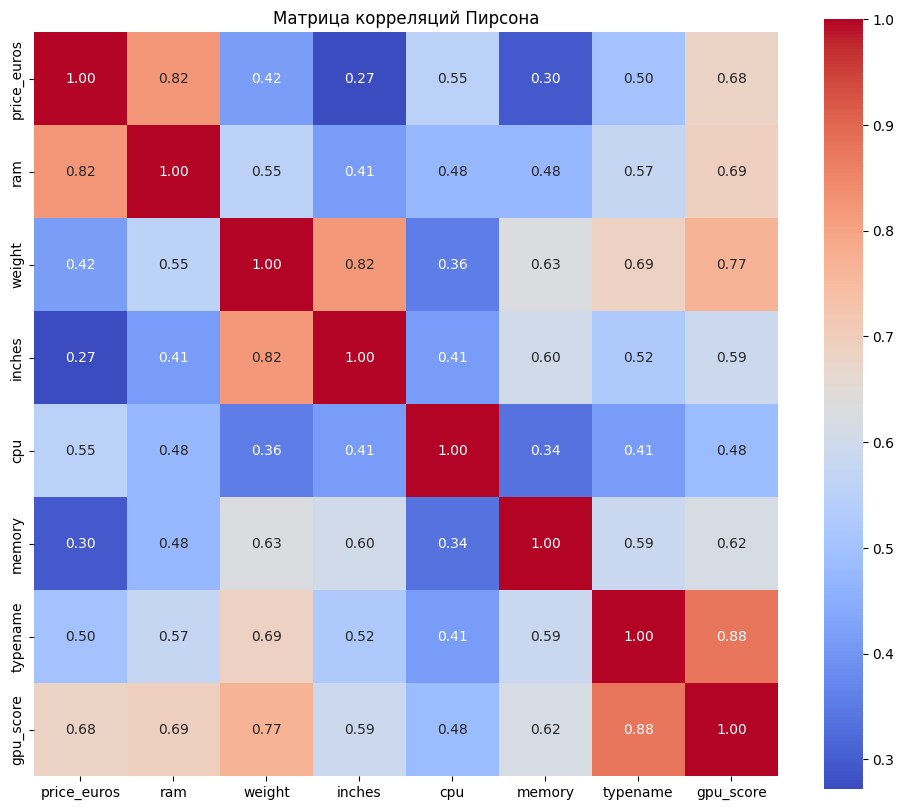

In [13]:
numeric_cols = ['price_euros', 'ram', 'weight',  'inches', 'cpu', 'memory', 'typename', 'gpu_score']
corr = df[numeric_cols].corr(method='pearson')


print("Коэффициенты корреляции Пирсона")
print(corr.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Матрица корреляций Пирсона')
plt.show()

In [36]:
print("Мультиколлинеарность")

X_cols = ["ram", "weight", "inches", "cpu", 'memory', 'typename', 'gpu']
X_vif  = df[X_cols].copy()
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame({"Переменная": X_cols, "VIF": [variance_inflation_factor(X_vif_const.values, i + 1) for i in range(len(X_cols))]})
print(vif_data.to_string(index=False))

Мультиколлинеарность


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [15]:
df_final = pd.DataFrame()
df_final['price_euros'] = df['price_euros']
df_final['ram'] = df['ram']
df_final['inches'] = df['inches']
df_final['cpu'] = df['cpu']
df_final['memory'] = df['memory']
df_final['typename'] = df['typename']

In [16]:
stat, p_value_normality = stats.shapiro(df_final['price_euros'])
print(f"Тест Шапиро-Уилка на нормальность Price_euros: p-value = {p_value_normality:.4f}")
if p_value_normality < 0.05:
    print("Распределение цены не нормальное")
else:
    print("Распределение цены нормальное.")

Тест Шапиро-Уилка на нормальность Price_euros: p-value = 0.0000
Распределение цены не нормальное


In [17]:
df_final['price_euros'] = np.log(df_final['price_euros'])
stat, p_value_normality = stats.shapiro(df_final['price_euros'])
print(f"Тест Шапиро-Уилка на нормальность Price_euros после логарифмирования: p-value = {p_value_normality:.4f}")
if p_value_normality < 0.05:
    print("Распределение цены не нормальное")
else:
    print("Распределение цены нормальное.")

Тест Шапиро-Уилка на нормальность Price_euros после логарифмирования: p-value = 0.4497
Распределение цены нормальное.


In [18]:
mean_log = np.mean(df_final['price_euros'])
std_log = np.std(df_final['price_euros'], ddof=1)
ks_stat, ks_p = stats.kstest(df_final['price_euros'], 'norm', args=(mean_log, std_log))

print(f"\nТест Колмогорова-Смирнова на ln:")
print(f"  Статистика: {ks_stat:.4f}")
print(f"  P-value:    {ks_p:.4e}")


Тест Колмогорова-Смирнова на ln:
  Статистика: 0.0693
  P-value:    6.9578e-01


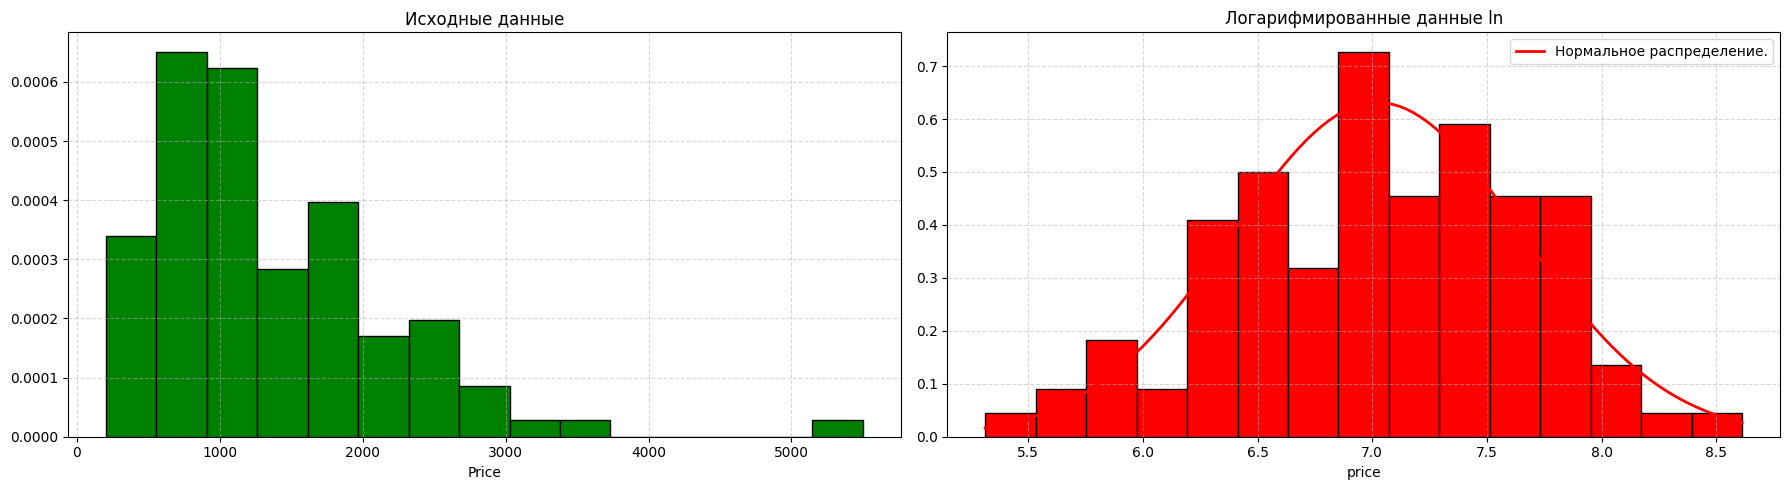

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(df['price_euros'], bins = int(bins_num), color='green', edgecolor='black', density=True)
axes[0].set_title(f'Исходные данные')
axes[0].set_xlabel('Price')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].hist(df_final['price_euros'], bins = int(bins_num), color='red', edgecolor='black', density=True)

x_norm = np.linspace(min(df_final['price_euros']), max(df_final['price_euros']), 100)
y_norm = stats.norm.pdf(x_norm, mean_log, std_log)
axes[1].plot(x_norm, y_norm, 'r-', linewidth=2, label='Нормальное распределение.')
axes[1].set_title(f'Логарифмированные данные ln')
axes[1].set_xlabel('price')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)


plt.tight_layout()
plt.show()

In [20]:
gaming   = df_final[df_final["typename"] == 1]["price_euros"]
nonGaming = df_final[df_final["typename"] == 0]["price_euros"]
t_stat, p_val = stats.ttest_ind(gaming, nonGaming)

print("Игровой против всех остальных")
print(f"Средняя цена Gaming = {gaming.mean():.2f} евро")
print(f"Средняя цена остальных = {nonGaming.mean():.2f} евро")
print(f"t = {t_stat:.4f}, p = {p_val:.4e}")
if p_val < 0.05:
    print("H0_a ОТВЕРГАЕТСЯ: Gaming-ноутбуки значимо дороже")
else:
    print("H0_a НЕ ОТВЕРГАЕТСЯ")

Игровой против всех остальных
Средняя цена Gaming = 7.55 евро
Средняя цена остальных = 6.87 евро
t = 5.0748, p = 1.8437e-06
H0_a ОТВЕРГАЕТСЯ: Gaming-ноутбуки значимо дороже


In [21]:
r_ram, p_ram = stats.pearsonr(df_final["ram"], df_final["price_euros"])
print("Проверка H0_b (корреляция ОЗУ–цена)")
print(f"r(ram, price) = {r_ram:.4f},  p = {p_ram:.4e}")
if p_ram < 0.05:
    print("H0_b ОТВЕРГАЕТСЯ: ОЗУ и цена значимо коррелируют")
else:
    print("H0_b НЕ ОТВЕРГАЕТСЯ")

Проверка H0_b (корреляция ОЗУ–цена)
r(ram, price) = 0.7204,  p = 2.9355e-17
H0_b ОТВЕРГАЕТСЯ: ОЗУ и цена значимо коррелируют


In [22]:
x_cols_redacted = ["ram", 'inches', "cpu", 'memory', 'typename']

X_all  = df_final[x_cols_redacted]
y_ln   = df_final["price_euros"]
X_sm   = sm.add_constant(X_all)

In [23]:
ols_model = sm.OLS(y_ln, X_sm).fit()
y_pred_ols = ols_model.predict(X_sm)

y_pred_orig = np.exp(y_pred_ols)
y_orig = np.exp(df_final["price_euros"])

mae_ols_ln  = mean_absolute_error(y_ln, y_pred_ols)

print("Коэффициенты и значимость:")
results_table = pd.DataFrame({
    "Коэффициент": ols_model.params,
    "Std.Error":   ols_model.bse,
    "t-статистика":ols_model.tvalues,
    "p-value":     ols_model.pvalues
}).round(6)
print(results_table)

eq = (f"\nln(Y) = {ols_model.params['const']:.4f}"
      f" + {ols_model.params['ram']:.4f}*X1"
      f" + {ols_model.params['inches']:.4f}*X2"
      f" + {ols_model.params['cpu']:.4f}*X3"
      f" + {ols_model.params['memory']:.4f}*X4"
      f" + {ols_model.params['typename']:.4f}*X5")
print(eq)

print(f"\nОсновные показатели модели:")
print(f"\nR^2 = {ols_model.rsquared:.6f}")
print(f"F-статистика = {ols_model.fvalue:.4f}")
print(f"Prob(F) = {ols_model.f_pvalue:.4e}")
print(f'MAE (log) = {mae_ols_ln}')

Коэффициенты и значимость:
          Коэффициент  Std.Error  t-статистика   p-value
const        6.368152   0.425105     14.980203  0.000000
ram          0.061132   0.007866      7.771857  0.000000
inches      -0.092649   0.030793     -3.008807  0.003366
cpu          0.627159   0.084661      7.407858  0.000000
memory      -0.000109   0.000098     -1.108521  0.270465
typename     0.145248   0.115633      1.256115  0.212187

ln(Y) = 6.3682 + 0.0611*X1 + -0.0926*X2 + 0.6272*X3 + -0.0001*X4 + 0.1452*X5

Основные показатели модели:

R^2 = 0.711066
F-статистика = 46.2667
Prob(F) = 6.9586e-24
MAE (log) = 0.2780746079543565


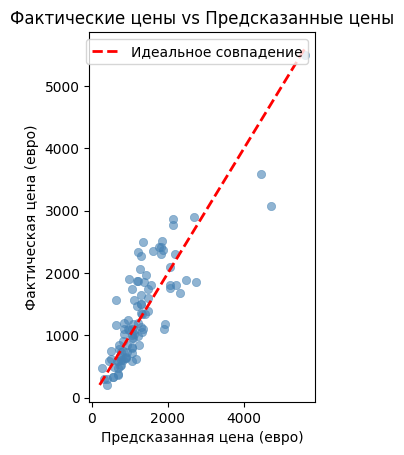

In [24]:
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_orig, y=y_orig, alpha=0.6, color='steelblue', edgecolor=None)

min_val = min(y_orig.min(), y_pred_orig.min())
max_val = max(y_orig.max(), y_pred_orig.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальное совпадение')

plt.title('Фактические цены vs Предсказанные цены')
plt.xlabel('Предсказанная цена (евро)')
plt.ylabel('Фактическая цена (евро)')
plt.legend()


# Раздел 3 Прогнозирование


In [25]:
adf_test = adfuller(df_final['price_euros'])
print(f'{adf_test[0]:.3f}, {adf_test[1]:.3f}')

data_ln = df_final['price_euros']
data = np.exp(df_final['price_euros'])
lag = 1
series = pd.Series(data)
acorr = series.autocorr(lag=lag)
print(f'{acorr:.3f}')

-7.576, 0.000
-0.077


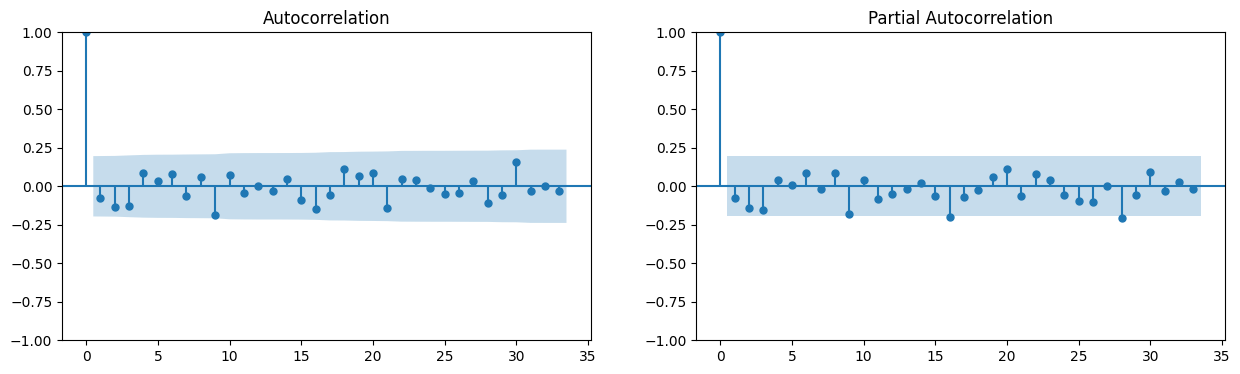

In [26]:
fig, ax = plt.subplots(1, 2, figsize = (15,4))
plot_acf(data, lags = (len(df_final['price_euros'])//3), ax = ax[0])
plot_pacf(data, lags = (len(df_final['price_euros'])//3), ax = ax[1], method = 'ywm')
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


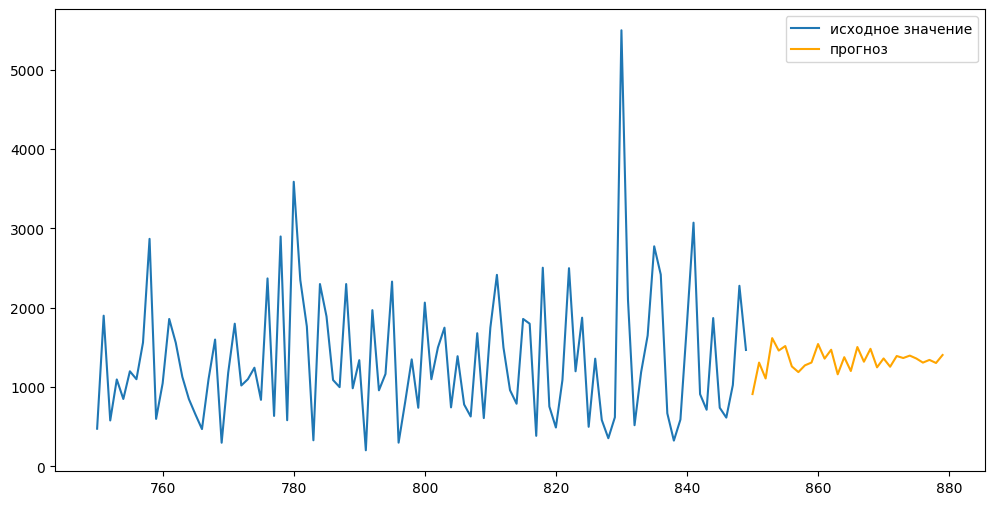

In [37]:
p, q = 5, 5
model = ARIMA(data, order = (p, 0, q))
res = model.fit()
fc = res.get_forecast(steps = 30)
fc_val = fc.predicted_mean


plt.figure(figsize = (12, 6))
plt.plot(data, label = 'исходное значение')
plt.plot(fc_val, color = 'orange', label = 'прогноз')
plt.legend()
plt.show()

In [42]:
p, q = 5, 5
model_ln = ARIMA(data_ln, order = (p, 0, q))
res_ln = model_ln.fit()
fc_ln = res_ln.get_forecast(steps = 30)
fc_ln_val = fc_ln.predicted_mean

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [43]:
x = df_final.drop('price_euros', axis = 1)
y = df_final['price_euros']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.3, random_state = 42, shuffle=False,)
mae = mean_absolute_error(y_test, fc_val)
print(mae)

x_ln = df_final.drop('price_euros', axis = 1)
y_ln = data_ln
x_ln_train, x_ln_test, y_ln_train, y_ln_test = train_test_split(x_ln, y_ln, test_size = 0.3, random_state = 42)
mae_ln = mean_absolute_error(y_ln_test, fc_ln_val)
print(mae_ln)

1330.0951700684125
0.5818523640181031


In [30]:
model_mod = ARIMA(endog=data, exog=df_final[x_cols_redacted], order=(12, 0, 5))
res_mod = model_mod.fit()
print(res_mod.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


                               SARIMAX Results                                
Dep. Variable:            price_euros   No. Observations:                  100
Model:                ARIMA(12, 0, 5)   Log Likelihood                -740.190
Date:                Mon, 15 Jun 2026   AIC                           1528.380
Time:                        01:53:26   BIC                           1590.905
Sample:                             0   HQIC                          1553.685
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        363.7827    858.013      0.424      0.672   -1317.893    2045.458
ram          110.1913     13.635      8.081      0.000      83.467     136.916
inches       -60.2075     57.756     -1.042      0.2

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [31]:
steps = 30
x_future = x_test
fc_mod_res = res_mod.get_forecast(steps=steps, exog=x_future)
fc_mod_mean = fc_mod_res.predicted_mean
conf_int = fc_mod_res.conf_int(alpha=0.05)
lower_bound = conf_int.iloc[:, 0]
upper_bound = conf_int.iloc[:, 1]

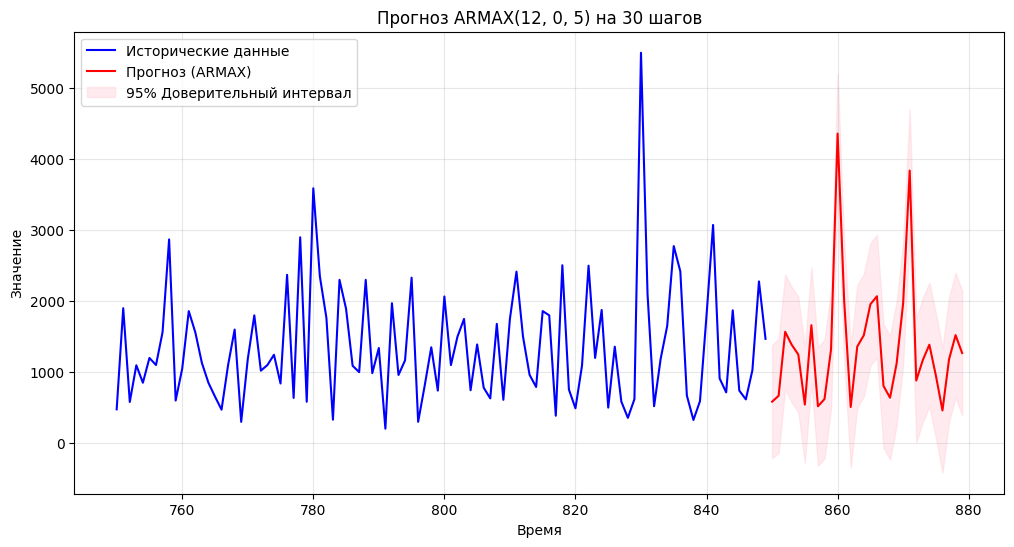

In [40]:
y = np.exp(y)
plt.figure(figsize=(12, 6))
plt.plot(y.index[-100:], y.values[-100:], label='Исторические данные', color='blue')
plt.plot(fc_mod_mean.index, fc_mod_mean, label='Прогноз (ARMAX)', color='red')
plt.fill_between(lower_bound.index, lower_bound, upper_bound, color='pink', alpha=0.3, label='95% Доверительный интервал')

plt.title('Прогноз ARMAX(12, 0, 5) на 30 шагов')
plt.xlabel('Время')
plt.ylabel('Значение')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
mae_mod = mean_absolute_error(y_test, fc_mod_mean)
print(mae_mod)

1361.654565469568
